/tmp/ipython-input-3-1844749146.py:74: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  X_all_tensor = torch.tensor(X_all, dtype=torch.float32).unsqueeze(1)


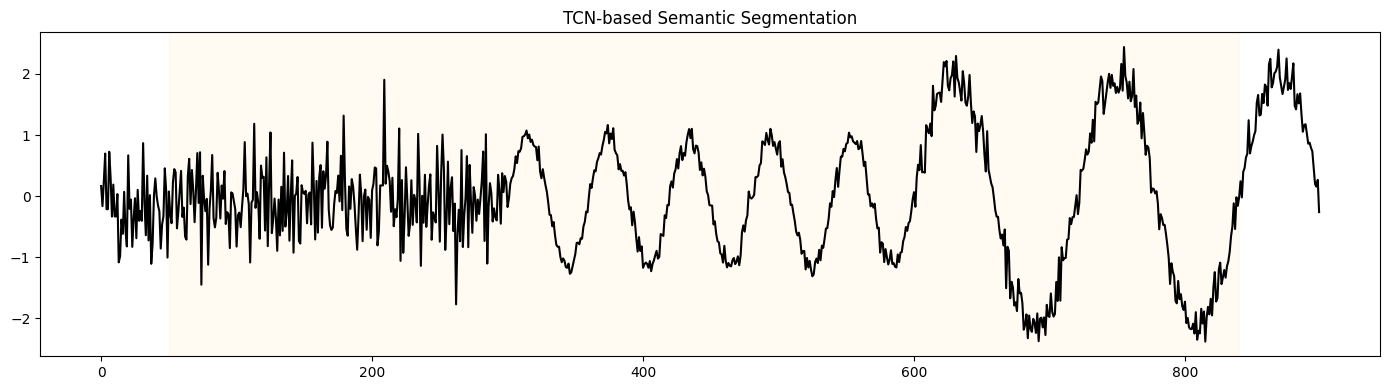

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd

# Generate synthetic segmented time series
np.random.seed(42)
seg1 = np.random.normal(0, 0.5, 300)
seg2 = np.sin(np.linspace(0, 10 * np.pi, 300)) + np.random.normal(0, 0.1, 300)
seg3 = 2 * np.sin(np.linspace(0, 5 * np.pi, 300)) + np.random.normal(0, 0.2, 300)
signal = np.concatenate([seg1, seg2, seg3])
labels = np.concatenate([np.zeros(300), np.ones(300), 2*np.ones(300)])
signal = (signal - signal.mean()) / signal.std()

# Prepare dataset
window_size = 100
stride = 10
X, y = [], []

for i in range(0, len(signal) - window_size, stride):
    X.append(signal[i:i+window_size])
    y.append(int(labels[i + window_size // 2]))

X = np.array(X)
y = np.array(y)

X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(y, dtype=torch.long)

dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

# Define lightweight TCN model
class TCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(4, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(8, 3)

    def forward(self, x):
        x = self.encoder(x)
        x = x.squeeze(-1)
        return self.fc(x)

model = TCN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train the model
for epoch in range(10):
    for batch_X, batch_y in loader:
        preds = model(batch_X)
        loss = criterion(preds, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# Predict on full sequence
model.eval()
X_all = []
indices = []
for i in range(0, len(signal) - window_size, stride):
    X_all.append(signal[i:i+window_size])
    indices.append(i + window_size // 2)

X_all_tensor = torch.tensor(X_all, dtype=torch.float32).unsqueeze(1)
with torch.no_grad():
    preds = model(X_all_tensor)
    pred_labels = torch.argmax(preds, dim=1).numpy()

# Visualize
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(signal, color='black')

colors = ['#e0f7fa', '#fff3e0', '#f3e5f5']
last_label = pred_labels[0]
start_idx = indices[0]

for i in range(1, len(pred_labels)):
    if pred_labels[i] != last_label or i == len(pred_labels) - 1:
        end_idx = indices[i]
        ax.axvspan(start_idx, end_idx, color=colors[last_label], alpha=0.4)
        start_idx = end_idx
        last_label = pred_labels[i]

ax.set_title("TCN-based Semantic Segmentation")
plt.tight_layout()
plt.show()
